# **DSC - 04) Boosting**

Emse,ble learning technique that combines multiple weak learners, such as shallow decision trees, to create a strong predictive model. It works iteratively by training learners on weighted data, where misclassified samples from previous iterations are given more weight encouraging the model to focus on difficult examples. Boosting reduces both buas and variance, improving accuracy.

**Notes:**
> Learning rate is also called "Shrinkage"

## **4.0) Theoretical background**

### **4.0.1) Adaboost**

Stands for **Adaptive Boosting**

**Key concepts**
> _Stump:_ A decision tree consisting of only one node and two leaves. They are weak learners.
> 
> _Weighting:_ In a forest of Stumps, not all learners have the same weight in the final prediction.
> 
> _Order:_ The order of creation of each stump is relevant, since the residuals of the first one will influence the second stimp, and so forth.
>
> _Sample importance:_ Each observation (individual) is assigned with a weight of importance for being correctly classified.

**Amount of saying**

To determine the weight assigned to each stomp when aggregating all the prediction of all of them, the following formula is used

$$ Amount\;of\;say = \frac{1}{2} log \left( \dfrac{1-Total \; Error}{Total \; Error} \right) $$

_where:_
> $Total \; Error = $ _the weightings sum of the missclassified samples_

_NOTE:_ When the Total Error is equal to 1 or 0, the formula is undefined, so a damping error is introduced.


**Updating the sample weights**

Once a first stump is selected, the sample weights are updated to provide with more importance those samples incorrectly classified. The new weights are computed as the following formula. When the observation was incorrecly classified use $(+)$ to increase its weight. When the observation was correctly classified use $(-)$ to decrease it's weight.

$$ New \; sample \; weight = sample \; weight \cdot e^{ \pm amount \; of \; say} $$

_NOTE:_ After computing the new weights, they should be normalized so they sum up to 1.

**Advancing to the next stump**

In order to influence the following stump based on the errors of the first one, one of the following methodologies could be applied:
> _Weighted Gini:_ Build the next stomp and compute the Gini impurity score based on the updated weights.
>
> _Resampling with PPS:_ Build a new dataframe with the same number of elements, sampling it with a Probability Proportional to Size, based on the updated weights of the previous stomp. After drawing the new sample, all weights are set as $1/n$, note that the misclassified samples are expected to appear more than once in the new dataframe.

**Making predictions**

After the algorithm is run, the _amount of saying_ of every stump predicting each class are summed, the one with a larger value is chosen as the predicted value.

### **4.0.2)  Gradient Boost**

Ensembles that uses gradient boosting are called _Gradient Boosting Machines (GBMs)_. The "Gradient" part of the name is inspired in Gradient Descend algorithm, which minimized a loss function to find the optimal value of parameters. For GBMs, the loss function is the residual value of the prediction of a sequence of decision trees.
 
Used for both regression and classification tasks that builds models incrementally by optimizing residual errors from previous models. It combines the prediction of multiple weak learners, typically decision rees, to create a strong predictive model. The core idea is to iteratively add models that correct the errors of the ensemble formed by preicous models, aiming to minimize a predefined loss function.

For regression purposes, the decision starts with the mean of all observations in the datasets. Then, a **Learning Rate** is used to incorporate the prediction of the residuals. The $LR$ is a factor that scales the prediction of residuals, its used to minimize the probability of overfitting. In other words, it scales the decision trees. A low Learning Rate (e.g. $0.1$) means that the residuals are corrected slowly, but it's better to take little steps in the right direction to reduce the variance in the testing data.

> $y_{pred} = mean + LR * tree_1 + LR * tree_2 $

The algorithm works in three main steps:
> 1) Fit a weak learner to the residuals of the previous predictin.
>
> 2) Calculate and update the model weights to reduce the overall loss
>
> 3) Repeat this process for a specified number of iterations or until the loss converges.

Focuses on sequentially improvbing the model by learning from its mistakes rather than training models independently and aggregating their precitions.

**Classification**

When GBM are used for classification purposes, the  residual is computed as. Note that $P(Acutal)$ is either $0$ ot $1$. The algoriothm is run using regression trees and it uses $log(odds)$ to quantify the probabilites. Note that a cut probability to define if either an observation belongs to certain class or not.

$residual = P(estimated) - P(actual)$

Some of the **advanteges** of GBMs are:

> - _High accuracy:_ The method ensures great results, but this comes with a high chance of overfitting
> 
> - _Generally scalable:_ Despite the fact that these cannot be trained in paralell, but in sequence, the implementation is quicl and efficient.
>
> - _Work well with missing data:_ Decision trees doesn't need implicit dat aimputation
>
> - _Don't require scaling:_ Another advantage inhereted from decision trees.

On the other hand, some of the **disadvantages** are:

> - Tuning too many hyperparameters might be time consuming
>
> - They can be difficult to interpeter (black box models)
>
> -  They don't perform well when extrapolating to values outside the range in the training set.
>
> -  They are prone to overfitting if too many hyperparameters are tuned.

### **4.0.3) XGBoost**

Designed to be used with large, complicated datasets, _XGBoost_ stands for Extreme Grtadient Boosting, is a powerful and widely used machine learning algorithm based on the graduent boosting, excels in predictive modeling tasks.

> An initial guess is taken as $0.5$, regardless if it's for regression or classification purposes.

**Similarity and Gain**  
A similarity score is then defined. It helps to quantify how much the leaves cluster similar Residuals.    
> $Similarity \; Score = \dfrac{(\sum_{i} res_i)^2}{Number \; of \; residuals + \lambda}$
>
> _where:_ $\lambda$ is called the _regularization parameter_

For classification purposes:

> $Similarity \; Score = \dfrac{1}{ \lambda + \sum [p_{previous} \cdot (1-p_{previous})] } $

In order to build an XGBoost tree, the Gains of each threshold is assessed between them, to select the one with a larger Gain, which is computed as:
> $Gain = Left_{similarity} + Right_{similarity} - Roit_{similarity}$

**Minimum Loss Reduction ( $\boldsymbol{\gamma}$ )**

COntrols wether a node will be split by setting a minimum Gain score. If the resultant Gain is not enough, the XGB tree won't split at that node. Nevertheless, if some of the child nodes are above the threshold, the parent node will remain, regardless if by itself is not enough.


**Approximate Greedy Algorithm**  
Check for every possible threshold for every possible variable in the dataset, would take too much time. Instead, the algorithm takes as candidates only the quantiles. Note that the quantiles are not obtained in a traditional fashion, instead, a weighting is assigned to each observation and the weighted-quantiles are used. In other words, the advantage of using the Weighted quantiles is that we get smaller quantiles when is needed.

**Relevant parameters**  
> $gamma:$ Minimum loss reduction requiredd to make a further partition on a leaf node of the tree. The larger the gamma is, the more conservative the algorithm will be.
>
> $alpha:$ L1 regularization term on weights. Increasing this value will make model more conservative. It's main usage is feature selection.
>
> $lambda:$ L2 regularization term on weights. Contrary to _alpha_, it doesn't make some weights equal to zero, but makes them small. It's main usage is to provide smoothness to the model.



. Increasing this value will make model more conservative. Normalised to number of training examples.

### **4.0.4) SMOTE (Synthetic Minority Oversampling Technique)**



Oversampling technique that allows to increase the samples in the minority dataset. Used to address class imbalance, particularly for classification problems. It works by creating synthetic samples fo the minority class rather than simply duplicating existing samples. This helps improve the performance of machine learning models by providing a more balanced representation of the classes.

**Algorithm**

> *1) Identify minority class*  
> SMOTE focuses in the class with less representation in the dataset
> 
> *2) Find nearest neighbours*  
> For each minority class sample, it identifies a specified number of nearest neighbors using a distance metric (commonly Euclidean distance).
> 
> *3) Generate synthetic samples*  
> New samples are created by interploating between two samples of the minority class. The new sample is chosen randomly as a point along the line segment conecting the two samples.
> 
> *4) Balance dataset*  
> The process is repeated as many times as needed to balance the dataset

**Advantages**
> _Avoid overfitting:_ Simply duplicating minority class samples may lead to overfitting. By creating new data points, SMOTE increases model generalization.
>
> _Improved Classifier Performance:_ Balanced dataset often improve the performance of classification models, particularly when using algorithms sensitive to class imbalance like decision trees or support vector machines.
>
> _Versatility:_ SMOTe can be used with varioues features tupes and classification algorithms

**Drawbacks**
> _Noise sensitiviy:_ SMOTE can amplofy noise in the minority class because it generates syntetic samples based on potentially noisy neighbours.
>
> _Over-simplification:_ SMOTE assumes that minority class instances can be interpolated linearly, which may not always hold true.

## **4.1) Prepare for execution**

### **4.1.1) Load libraries**

In [144]:
# General purpose
import os
import pandas as pd
import numpy as np

# Data Visualizaiton
import matplotlib.pyplot as plt
import seaborn as sns

# Perform XGBoost algorithm
import xgboost as xgb

# Decision tree to compare
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# AdaBoost and Gradient boost
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Auxiliary to Boosting
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

# Mosaicplot
from statsmodels.graphics.mosaicplot import mosaic

# Used to balance the dataset
from imblearn.over_sampling import SMOTE

## **4.2) Used dataset**

### **4.2.1) Load dataset**

In [6]:
# Define main folder and read data
main_folder = os.getcwd()
df_raw = pd.read_csv(main_folder+"/Data/Telco Customer Churn.csv")
df_data = df_raw.copy()

# Block breaker, show head
df_data.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


### **4.2.2) Prepare data**

#### **4.2.2.1) Remove columns with a single value**

In [7]:
# Detect columns with a single value across the entire df
single_value = df_data.nunique()
single_value = single_value[single_value==1]

# Remove those columns from the df
df_data.drop(single_value.index, axis=1, inplace=True)

#### **4.2.2.2) Remove unnecessary columns**

The selected columns are posterior to the client's decision to churn, so these are not used in the prediction.

In [8]:
df_data.drop(["Churn Value", "Churn Score", "CLTV", "Churn Reason"], axis=1, inplace=True)

#### **4.2.2.3) Remove not helpful columns**

These columns doesn't provide predictive potential for the goals of the project

In [9]:
df_data.drop(["CustomerID", "Lat Long"], axis=1, inplace=True)

#### **4.2.2.4) Rename columns**

Blank spaces from column names are replaced with underscores

In [10]:
df_data.columns = df_data.columns.str.replace(" ", "_")

#### **4.2.2.5) Remove blank spaces within the DF**

XGBoost requires that all the values within the DF are free of " " blank spaces, all the categorical columns are modified to comply.

In [11]:
# Define a mask for categorical variables and replace any potential blank space
numerical = ["Zip_Code", "Latitude", "Longitude", "Tenure_Months", "Monthly_Charges", "Total_Charges"]
categorical = ~df_data.columns.isin(["Zip_Code", "Latitude", "Longitude", "Monthly_Charges", "Total_Charges"])
categorical = df_data.columns[categorical].to_list()
df_data.loc[:, categorical] = df_data.loc[:, categorical].replace(" ", "_", regex=True)

## **4.3) Deal with missing values**

### **4.3.1) Check for missing data**
Dtype and non-null count is checked for all columns

In [12]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Zip_Code           7043 non-null   int64  
 2   Latitude           7043 non-null   float64
 3   Longitude          7043 non-null   float64
 4   Gender             7043 non-null   object 
 5   Senior_Citizen     7043 non-null   object 
 6   Partner            7043 non-null   object 
 7   Dependents         7043 non-null   object 
 8   Tenure_Months      7043 non-null   int64  
 9   Phone_Service      7043 non-null   object 
 10  Multiple_Lines     7043 non-null   object 
 11  Internet_Service   7043 non-null   object 
 12  Online_Security    7043 non-null   object 
 13  Online_Backup      7043 non-null   object 
 14  Device_Protection  7043 non-null   object 
 15  Tech_Support       7043 non-null   object 
 16  Streaming_TV       7043 

It's noticed that Total_Charges is encoded as an object variable. This is because the tenure months is equal to 0 and there haven't been any charfes yet. The issue is addressed by setting this values to "0" and the dtype of the column is changed.

In [13]:
# Change Null values to 0 and change dtype of column
missing = pd.to_numeric(df_data["Total_Charges"], errors="coerce")
df_data.loc[missing[missing.isna()].index, "Total_Charges"] = 0
df_data["Total_Charges"] = pd.to_numeric(df_data["Total_Charges"])

## **3.4) Exploratory Data Analysis**

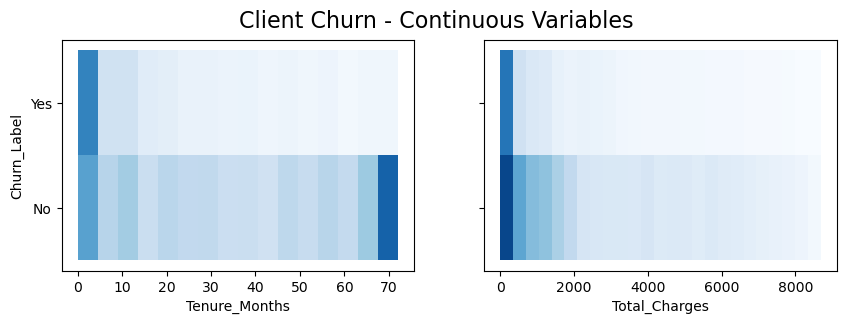

In [14]:
# Plot the occurrence of leaving for given variables
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,3), sharey=True)
sns.histplot(x="Tenure_Months", y="Churn_Label", data=df_data, cmap="Blues", ax=ax1, vmin=0, vmax=1000)
sns.histplot(x="Total_Charges", y="Churn_Label", data=df_data, cmap="Blues", ax=ax2, vmin=0, vmax=1000)

# Show plot
plt.tight_layout
plt.suptitle("Client Churn - Continuous Variables", fontsize=16)
plt.show()

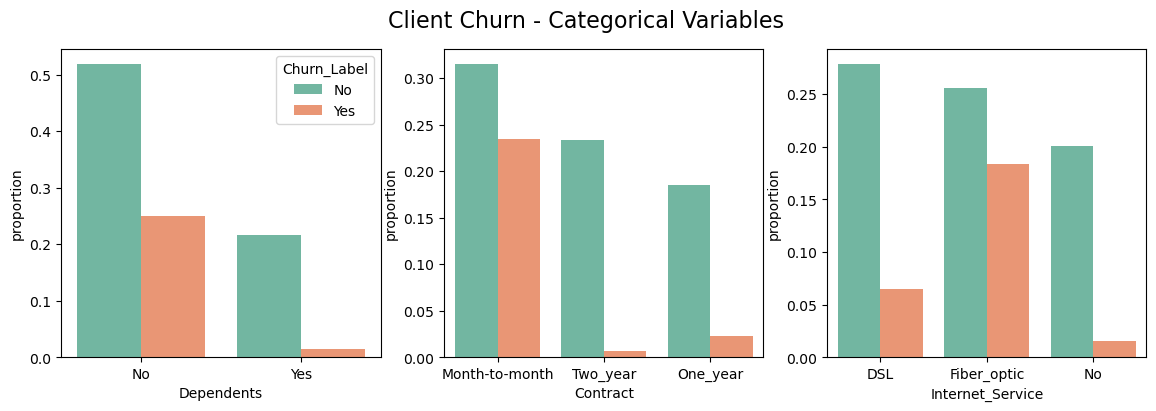

In [15]:
# Create bar plots to check proportions
fig, (ax1,ax2,ax3) = plt.subplots(1,3, figsize=(14,4))
sns.countplot(x="Dependents", data=df_data, hue="Churn_Label", stat="proportion", palette="Set2", hue_order=["No", "Yes"], ax=ax1)
sns.countplot(x="Contract", data=df_data, hue="Churn_Label", stat="proportion", palette="Set2",
              hue_order=["No", "Yes"], legend=False, ax=ax2)
sns.countplot(x="Internet_Service", data=df_data, hue="Churn_Label", stat="proportion", palette="Set2", hue_order=["No", "Yes"], 
              legend=False, ax=ax3)

# Show plot
plt.tight_layout
plt.suptitle("Client Churn - Categorical Variables", fontsize=16)
plt.show()

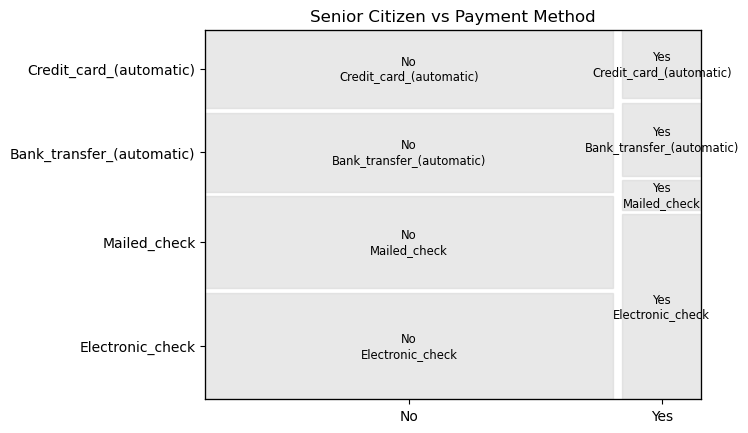

In [16]:
import pandas as pd

import matplotlib.pyplot as plt


data = {}
for index, count in df_data[["Senior_Citizen", "Payment_Method"]].value_counts().items():
    data[index] = count

props = lambda key:{"color":"lightgray", "alpha":0.50}
mosaic(data, gap=0.02, properties=props)
plt.title("Senior Citizen vs Payment Method")
plt.show()

## **3.5) Shape data for modelation**

The objective of the NB is to compare each boosting method, so the same data need to be imput for the three models

In [17]:
# Define features and target variables
features = df_data.columns[~df_data.columns.isin(["City", "Zip_Code", "Latitude", "Longitude", "Churn_Label"])]
target = "Churn_Label"

# State predictive dataset and the target variable
X = df_data[features].copy()
X = pd.get_dummies(X, columns=features[~features.isin(["Tenure_Months", "Monthly_Charges", "Total_Charges"])])
y = df_data[target]
y = (y == "Yes").astype(int)


# Split in train and test
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=314159, stratify=y, test_size=0.20)

## **3.6) AdaBoost**

### **3.6.1) Balance dataset**

Synthetic observations for minority class are created using SMOTE algorithm.

In [149]:
X_upsampled, y_upsampled = SMOTE(random_state=314159).fit_resample(X_train, y_train)

### **3.6.2) Fit a model with default settings**

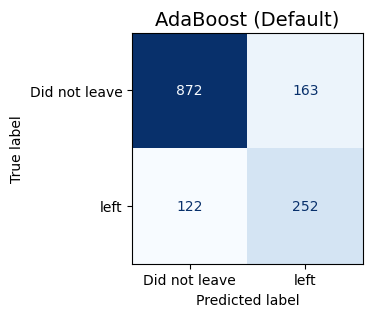

In [150]:
# Run the XGB tree
model_ab = AdaBoostClassifier(random_state=314159, algorithm="SAMME")
model_ab.fit(X_upsampled, y_upsampled)

# Obtain predicted classes
predicted = model_ab.predict(X_test)

# Plot confusion matrix
fig, ax1 = plt.subplots(1,1, figsize=(3,3))
ConfusionMatrixDisplay.from_predictions(y_test, predicted, display_labels=["Did not leave", "left"],
                                        cmap="Blues", colorbar=False, ax=ax1)
plt.title("AdaBoost (Default)", fontsize=14)
plt.show()

### **3.6.3) Enhance prediction of leaving clients**

#### **3.8.1) Perform Grid Search**

In [95]:
# Best params grid, optimized given an iteration
parameters_grid = {"n_estimators":[40,50,55], "learning_rate":[0.75,0.49,0.50]}

# Define model and perform the grid search
model_ab = AdaBoostClassifier(random_state=314159, algorithm="SAMME")
gridsearch_ab = GridSearchCV(model_ab, parameters_grid, scoring="accuracy", cv=3).fit(X_resampled, y_resampled)

# Block breaker
print("="*100)
print(gridsearch_ab.best_params_)
print("="*100)

{'learning_rate': 0.49, 'n_estimators': 55}


#### **3.8.1) Test tuned model**

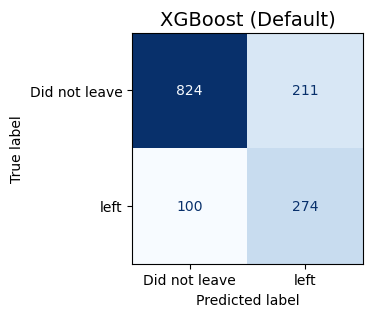

In [96]:
model_ab = AdaBoostClassifier(random_state=314159, algorithm="SAMME", learning_rate=0.40, n_estimators=55)
model_ab.fit(X_upsampled, y_upsampled)

# Obtain predicted classes
predicted = model_ab.predict(X_test)

# Plot confusion matrix
fig, ax1 = plt.subplots(1,1, figsize=(3,3))
ConfusionMatrixDisplay.from_predictions(y_test, predicted, display_labels=["Did not leave", "left"],
                                        cmap="Blues", colorbar=False, ax=ax1)
plt.title("XGBoost (Default)", fontsize=14)
plt.show()

## **3.7) Gradient Boost**

### **3.7.1) Balance dataset**

For this Boosting algorithm, the balancing techinque is a downsampling, which consist on randomly select an equal number of samples in the majority class as in the minority class.

In [143]:
# Perform downsamplig
n_minority = y_train.value_counts().loc[1]
index_downsample = y_train[y_train==0].sample(n_minority, random_state=314159).index
X_downsampled = pd.concat([X_train.loc[index_downsample,:], X_train[y_train==1]])
y_downsampled = pd.concat([y_train.loc[index_downsample], y_train[y_train==1]])

### **3.7.2) Fit a model with default settings**

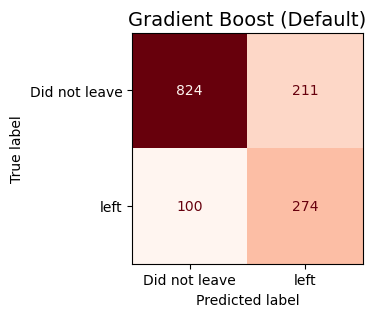

In [146]:
model_gb = GradientBoostingClassifier(random_state=314159)
model_gb.fit(X_downsampled, y_downsampled)

# Obtain predicted classes
predicted = model_ab.predict(X_test)

# Plot confusion matrix
fig, ax1 = plt.subplots(1,1, figsize=(3,3))
ConfusionMatrixDisplay.from_predictions(y_test, predicted, display_labels=["Did not leave", "left"],
                                        cmap="Reds", colorbar=False, ax=ax1)
plt.title("Gradient Boost (Default)", fontsize=14)
plt.show()

### **3.7.3) Enhance prediction of leaving clients**

#### **3.8.1) Perform Grid Search**

In [160]:
# Best params grid, optimized given an iteration
parameters_grid = {"learning_rate":[0.150,0.125,0.130], "n_estimators":[125],
                  "min_samples_split":[2,4], "min_samples_leaf":[2], "max_depth":[2,3]}

# Define model and perform the grid search
model_gb = GradientBoostingClassifier(random_state=314159)
gridsearch_ab = GridSearchCV(model_gb, parameters_grid, verbose=True,scoring="accuracy", cv=3).fit(X_downsampled, y_downsampled)

# Block breaker
print("="*100)
print(gridsearch_ab.best_params_)
print("="*100)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
{'learning_rate': 0.125, 'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 125}


#### **3.8.1) Test tuned model**

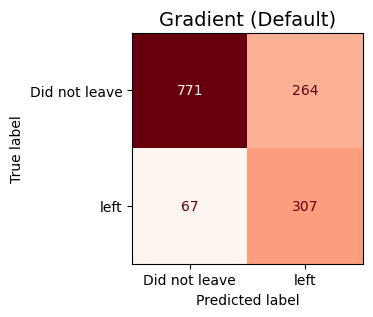

In [162]:
model_gb = GradientBoostingClassifier(random_state=314159,
    learning_rate=0.125, max_depth=2, min_samples_leaf=2, min_samples_split=2, n_estimators=125)
model_ab.fit(X_downsampled, y_downsampled)

# Obtain predicted classes
predicted = model_ab.predict(X_test)

# Plot confusion matrix
fig, ax1 = plt.subplots(1,1, figsize=(3,3))
ConfusionMatrixDisplay.from_predictions(y_test, predicted, display_labels=["Did not leave", "left"],
                                        cmap="Reds", colorbar=False, ax=ax1)
plt.title("Gradient (Default)", fontsize=14)
plt.show()

## **3.8) XGBoost**

### **3.8.1) Fit a model with default settings**

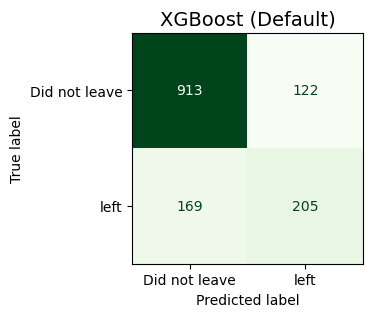

In [163]:
# Run the XGB tree
model_xgb = xgb.XGBClassifier(objective="binary:logistic", seed=314159)
model_xgb.fit(X_train, y_train, verbose=False, eval_set=[(X_test, y_test)])

# Obtain predicted classes
predicted = model_xgb.predict(X_test)

# Plot confusion matrix
fig, ax1 = plt.subplots(1,1, figsize=(3,3))
ConfusionMatrixDisplay.from_predictions(y_test, predicted, display_labels=["Did not leave", "left"],
                                        cmap="Greens", colorbar=False, ax=ax1)
plt.title("XGBoost (Default)", fontsize=14)
plt.show()

### **3.8.2) Enhance prediction of outgoing people**

#### **3.8.2.1) Perform Grid Search**

Due the imblanace of the data, the model is better at predicting those that do not leave the company. In order to solve this issue by weightingh the observations. It imposses a greater penalty for misclassifying the minority class.

In [188]:
# Best params grid, optimized given an iteration
parameters_grid = {"max_depth":[2], "learning_rate":[0.075],
                   "gamma":[0], "reg_lambda":[0.05,0.075,0.10],
                   "scale_pos_weight":[2.0]}

# Define model and perform the grid search
model_xgb = xgb.XGBClassifier(objective="binary:logistic", seed=314159)
gridsearch_xgb = GridSearchCV(model_xgb, parameters_grid, scoring="f1_weighted", cv=3).fit(X_test, y_test)

# Block breaker
print("="*100)
print(gridsearch_xgb.best_params_)
print("="*100)

{'gamma': 0, 'learning_rate': 0.075, 'max_depth': 2, 'reg_lambda': 0.05, 'scale_pos_weight': 2.0}


#### **3.8.2.2) Test tuned model**

The grid search improved the prediction capabilities for those clients that won't leave the company. Nevertheless, the capability of detecting churn clients was not possible to be increased. Regardless of these results, the model can help reduce in half the leaving clients.

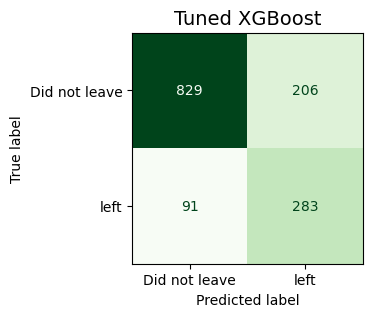

In [197]:
# Fit the tuned model
model_xgb = xgb.XGBClassifier(objective="binary:logistic", seed=314159,
                  gamma=0, learning_rate=0.075, max_depth=2, reg_lambda=0.05, scale_pos_weight=2.0)
model_xgb.fit(X_train, y_train, verbose=False, eval_set=[(X_test, y_test)])

# Obtain predicted classes
predicted = model_xgb.predict(X_test)

# Plot confusion matrix
fig, ax1 = plt.subplots(1,1, figsize=(3,3))
ConfusionMatrixDisplay.from_predictions(y_test, predicted, display_labels=["Did not leave", "left"],
                                        cmap="Greens", colorbar=False, ax=ax1)
plt.title("Tuned XGBoost", fontsize=14)
plt.show()

### **3.8.3) Feature importance**

Using L1 regularization for feature selection in XGBoost involves leveraging its ability to shrink some feature weights to zero, effectively identifying and discarding irrelevarnt or less important features. To do so, a tree with $alpha=1$ is trained.

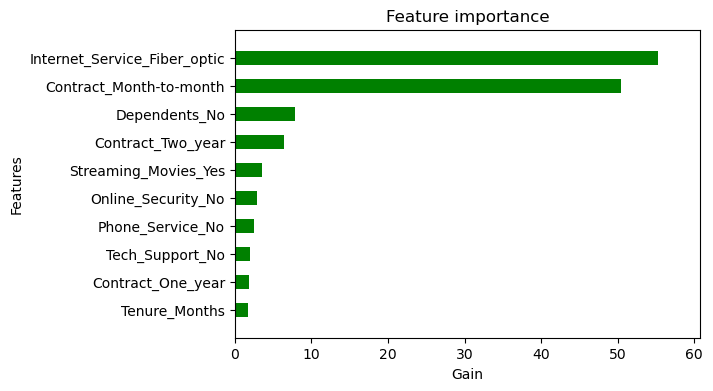

In [169]:
# Train a model to identify feature importance
model_xgb = xgb.XGBClassifier(objective="binary:logistic", seed=314159, alpha=1.0)
model_xgb.fit(X_train, y_train, verbose=False, eval_set=[(X_test, y_test)])

# Plot feature importance
fig, ax1 = plt.subplots(1,1, figsize=(6,4))
xgb.plot_importance(model_xgb, importance_type="gain", xlabel="Gain", grid=False, height=0.5, max_num_features=10,
                    show_values=False, ax=ax1, color="green")
plt.show()